---

# Task 1: Familiarize Yourself with the Dataset

There are two main subtasks:  
1. Load the four data files that are part of this dataset.  
2. Explore each dataset and define the data types of each column. Describe the contents of each column, including the nature of the data values. Follow a similar approach as demonstrated in the lecture and tutorial. Discuss the shape of the data, value ranges, and possible categories. Convert any data into a more appropriate format if needed.  

Add as many code and markdown cells as necessary below. Typically, you should perform one type of investigation per code cell with output, and then comment on the results in a markdown cell below it.  

After completing the analysis, write a concise summary in the **Task 1: summary report** cell at the end. The final report should succinctly summarize the main characteristics of each data file, how they relate to each other, and any notable features.


In [420]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.stats import norm

### Loading the Four Data Files

In [421]:
# Load each .csv into a dataframe
df_sessions = pd.read_csv("data/sessions.csv")
df_streamers = pd.read_csv("data/streamers.csv")
df_streams = pd.read_csv("data/streams.csv")
df_viewers = pd.read_csv("data/viewers.csv")

Each .csv file is loaded into its own DataFrame.

### sessions.csv

*Columns*

- *session_id*: **Numerical**
    - the id of the session a viewer watches a stream (the id starts with SES) (string)
- *viewer_id*: **Numerical**
    - the id of the viewer (the id starts with VWR) (string)
- *streamer_id*: **Numerical**
    - the id of the streamer (the id starts with STR) (string)
- *stream_id*: **Numerical**
    - the id of the stream (the id starts with SM) (string)
- *started_at*: **Numerical**
    - the date and time the viewer started watching (year-month-date hour:min:sec format) (string)
- *ended_at*: **Numerical**
    - the date and time the viewer stopped watching (year-month-date hour:min:sec format) (string)
- *duration_mins*: **Numerical**
    - how long and sessions lastes in minutes (integer)
- *chat_messanges_sent*: **Numerical**
    - number of chat messages sent during the session (integer)
- *bits_cheered*: **Numerical**
    - number of bits cheered during the session (integer)
- *followed_during*: **Categorical**
    - did the viewer follow the streamer during the session (boolean)
- *subscribed_during*: **Categorical**
    - did the viewer subscribe to the streamer during the session (boolean)

In [422]:
df_sessions.head()

,session_id,viewer_id,streamer_id,stream_id,started_at,ended_at,duration_mins,chat_messages_sent,bits_cheered,followed_during,subscribed_during
0,SES000001,VWR00938,STR0055,SM00860,2024-01-18 19:16:00,2024-01-18 20:28:00,72,0,0,False,False
1,SES000002,VWR00804,STR0034,SM00542,2024-01-04 17:11:00,2024-01-04 19:41:00,150,11,0,False,False
2,SES000003,VWR00704,STR0008,SM00124,2024-02-15 15:11:00,2024-02-15 16:53:00,102,5,0,False,False
3,SES000004,VWR00926,STR0024,SM00373,2024-01-18 19:59:00,2024-01-18 20:56:00,57,3,9663,False,False
4,SES000005,VWR00883,STR0008,SM00120,2024-03-19 20:08:00,2024-03-19 20:22:00,14,7,0,False,False


Displayed to first 5 rows of sessions.csv in order to show the names of the columns and the types of their data.

#### Shape of the Data

Text(0.5, 1.0, 'number of sessions vs. duration_mins')

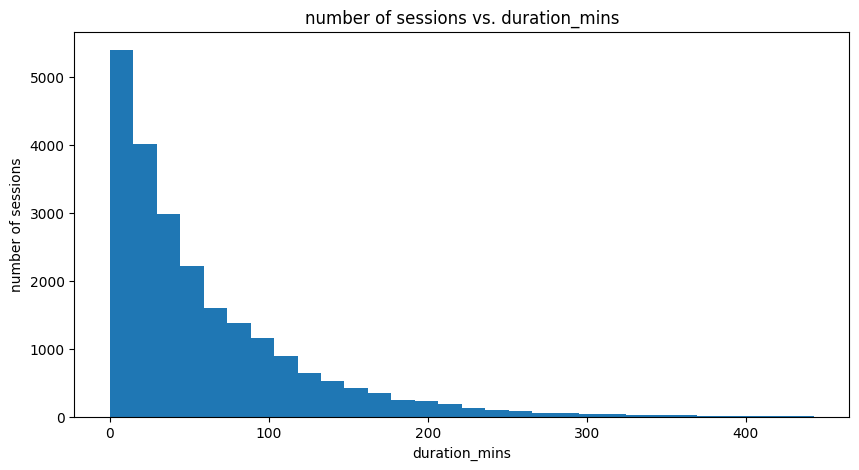

In [423]:
plt.figure(figsize=(10, 5))
plt.hist(df_sessions["duration_mins"], bins=30)
plt.xlabel("duration_mins")
plt.ylabel("number of sessions")
plt.title("number of sessions vs. duration_mins")

Most viewers tend to watch a stream for a few minutes, and as the duration_mins increases, the number of sessions decreases significantly.

Text(0.5, 1.0, 'number of sessions vs. chat_messages_sent')

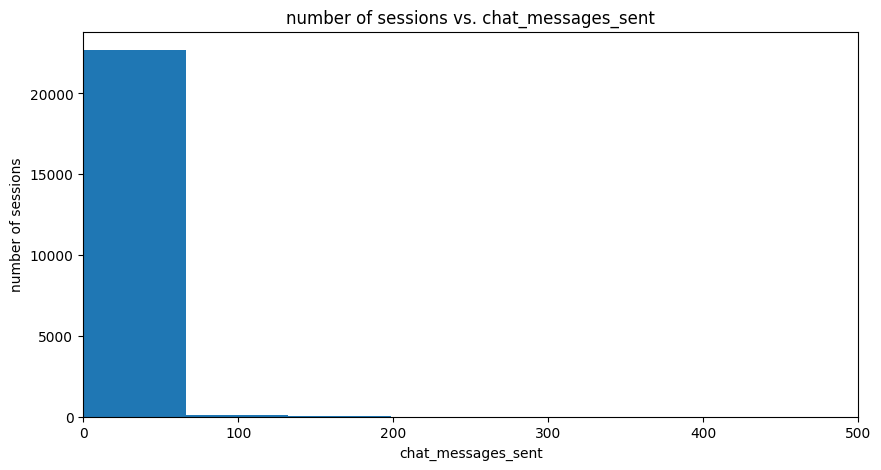

In [424]:
plt.figure(figsize=(10, 5))
plt.hist(df_sessions["chat_messages_sent"], bins=30)
plt.xlim(0, 500)
plt.xlabel("chat_messages_sent")
plt.ylabel("number of sessions")
plt.title("number of sessions vs. chat_messages_sent")

Most sessions have the number of chat messages that are less than 100. I think this means that viewers do not chat much during sessions. I excluded the data with the most amount of messages sent to see where most of the data is on the x axis. The most amount of chat messages sent is 1987 messages.

Text(0.5, 1.0, 'number of sessions vs. bits_cheered')

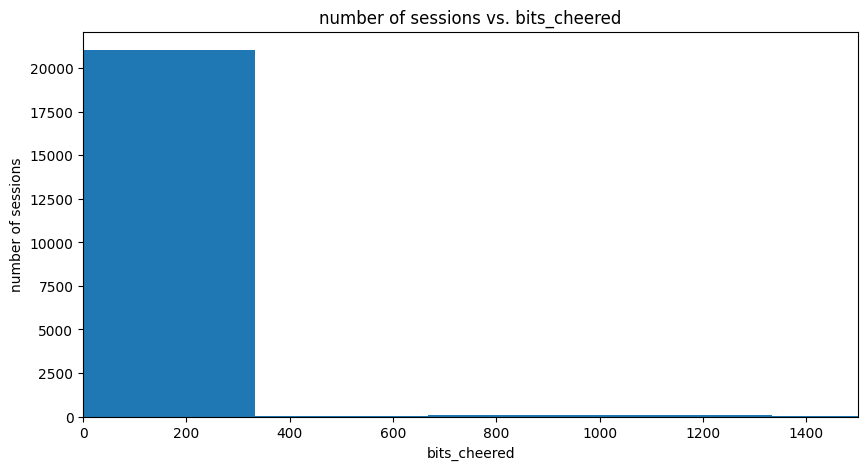

In [425]:
plt.figure(figsize=(10, 5))
plt.hist(df_sessions["bits_cheered"], bins=30)
plt.xlim(0, 1500)
plt.xlabel("bits_cheered")
plt.ylabel("number of sessions")
plt.title("number of sessions vs. bits_cheered")

This plot of number of sessions vs. bits_cheered has the same shape as the previous plot for number of messages sent. It is a measure of participation. I excluded the outliers same as in the previous plot. The most amount of bits cheered is 10000.

#### Value Ranges

In [426]:
print(
    "Value Range of duration_mins: " +
    str(df_sessions["duration_mins"].min()) +
    " to "  + str(df_sessions["duration_mins"].max())
)

print(
    "Value Range of chat_messages_sent: " +
    str(df_sessions["chat_messages_sent"].min()) +
    " to "  + str(df_sessions["chat_messages_sent"].max())
)

print(
    "Value Range of bits_cheered: " +
    str(df_sessions["bits_cheered"].min()) +
    " to "  + str(df_sessions["bits_cheered"].max())
)

Value Range of duration_mins: 0 to 443
Value Range of chat_messages_sent: 0 to 1987
Value Range of bits_cheered: 0 to 10000


These show the range of values for the columns duration_mins, chat_messages_sent, and bits_cheered.

#### Possible Categories

In [427]:
print("Possible Categories of followed_during: " + str(df_sessions["followed_during"].unique()))
print("Possible Categories of subcribed_during: " + str(df_sessions["subscribed_during"].unique()))

Possible Categories of followed_during: [False  True]
Possible Categories of subcribed_during: [False  True]


Both columns here have boolean values and are therfore categories.

### streamers.csv

*Columns*

- *streamer_id*: **Numerical**
    - the id of the streamer (the id starts with STR) (string)
- *streamer_name*: **Unstructured**
    - the name of the streamer (string)
- *category*: **Categorical**
    - the type of streams the streamer does (string)
- *language*: **Categorical**
    - the language used during the streams (string)
- *partner_status*: **Categorical**
    - does the streamer have a partner (boolean)
- *total_followers*: **Numerical**
    - the total amount of followers the streamer has (integer)
- *avg_concurrent_viewers*: **Numerical**
    - average concurrent viewers per stream (integer)

In [428]:
df_streamers.head()

,streamer_id,streamer_name,category,language,partner_status,total_followers,avg_concurrent_viewers
0,STR0001,xQc,Just Chatting,English,True,11500000,138706
1,STR0002,Pokimane,Just Chatting,English,True,-25551,71660
2,STR0003,HasanAbi,Just Chatting,English,True,2600000,34220
3,STR0004,Amouranth,Just Chatting,English,True,6200000,68607
4,STR0005,Mizkif,Just Chatting,English,True,2100000,6771


Displayed to first 5 rows of sessions.csv in order to show the names of the columns and the types of their data.

#### Shape of the Data

Text(0.5, 1.0, 'number of streamers vs. total_followers')

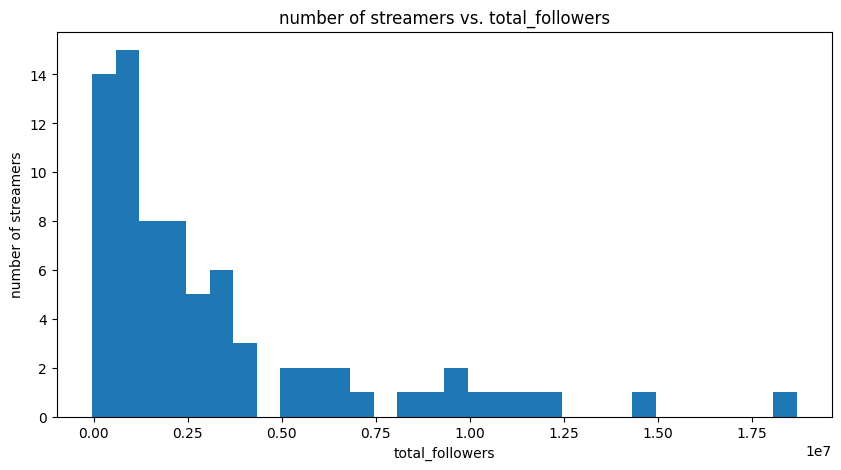

In [429]:
plt.figure(figsize=(10, 5))
plt.hist(df_streamers["total_followers"], bins=30)
plt.xlabel("total_followers")
plt.ylabel("number of streamers")
plt.title("number of streamers vs. total_followers")

This plot has a similar shape to the number of sessions vs. duration_mins plot, but is not continuous. There are a lot of streamers with low follower counts and a few streams with high follower counts.

Text(0.5, 1.0, 'number of streamers vs. avg_concurrent_viewers')

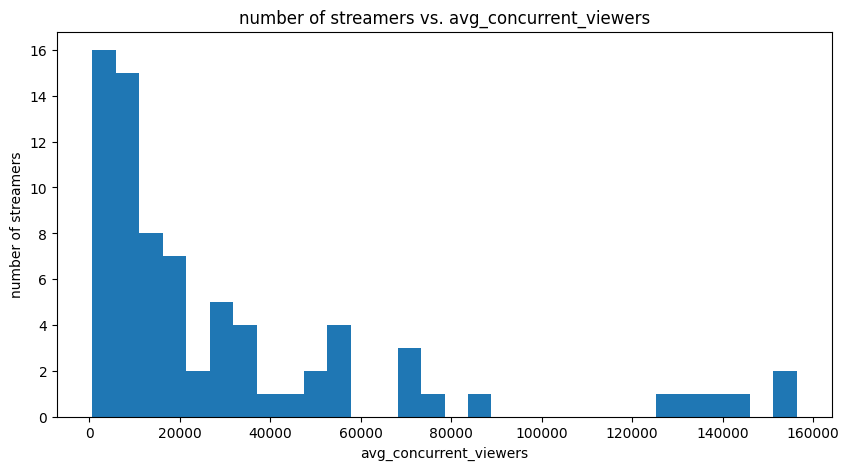

In [430]:
plt.figure(figsize=(10, 5))
plt.hist(df_streamers["avg_concurrent_viewers"], bins=30)
plt.xlabel("avg_concurrent_viewers")
plt.ylabel("number of streamers")
plt.title("number of streamers vs. avg_concurrent_viewers")

This plot has a similar shape to the previous plot and is not continuous. There is a slight increase in average concurrent viewers to the right most of the plot. Most streamers do not have a lot of  concurrent viewers conpared to the right most values.

#### Value Ranges

In [431]:
print(
    "Value Range of total_followers: " +
    str(df_streamers["total_followers"].min()) +
    " to "  + str(df_streamers["total_followers"].max())
)

print(
    "Value Range of avg_concurrent_viewers: " +
    str(df_streamers["avg_concurrent_viewers"].min()) +
    " to "  + str(df_streamers["avg_concurrent_viewers"].max())
)

Value Range of total_followers: -46964 to 18700000
Value Range of avg_concurrent_viewers: 634 to 156401


The minimum value for total_followers does not make sense becuase there can not be a nagative amount of folowers. avg_concurrent_viewers' value range makes sense.

#### Possible Categories

In [432]:
print("Possible Categories of category: " + str(df_streamers["category"].unique()))
print("Possible Categories of language: " + str(df_streamers["language"].unique()))
print("Possible Categories of partner_status: " + str(df_streamers["partner_status"].unique()))

Possible Categories of category: <StringArray>
['Just Chatting', 'FPS', 'MOBA', 'IRL', 'Creative', 'Sports']
Length: 6, dtype: str
Possible Categories of language: <StringArray>
['English', 'Spanish', nan, 'Korean', 'Portuguese']
Length: 5, dtype: str
Possible Categories of partner_status: [ True False]


The categories for the language column has a NaN value which needs data cleaning.

### streams.csv

*Columns*

- *stream_id*: **Numerical**
    - the id of the stream (the id starts with SM) (string)
- *streamer_id*: **Numerical**
    - the id of the streamer (the id starts with STR) (string)
- *started_at*: **Numerical**
    - the date and time the stream started (year-month-date hour:min:sec format) (string)
- *ended_at*: **Numerical**
    - the date and time the stream ended (year-month-date hour:min:sec format) (string)
- *stream_duration_hrs*: **Numerical**
    - how long the stream lasted in hours (float)
- *category*: **Categorical**
    - the type of stream (string)
- *peak_viewers*: **Numerical**
    - the highest viewer count during the stream (float)
- *title_has_hype_word*: **Categorical**
    - if the title of the stream has the word hype (boolean)
- *was_raid*: **Categorical**
    - of the stream was raided (boolean)

In [433]:
df_streams.head()

,stream_id,streamer_id,started_at,ended_at,stream_duration_hrs,category,peak_viewers,title_has_hype_word,was_raid
0,SM00001,STR0001,2024-02-14 18:00:00,2024-02-14 21:00:00,3.0,Just Chatting,108989.0,False,True
1,SM00002,STR0001,2024-01-28 18:00:00,2024-01-28 21:00:00,3.0,Just Chatting,51635.0,True,False
2,SM00003,STR0001,2024-01-31 09:00:00,2024-01-31 16:00:00,7.0,Just Chatting,212127.0,False,False
3,SM00004,STR0001,2024-03-03 14:00:00,2024-03-03 21:00:00,7.0,Just Chatting,186745.0,False,True
4,SM00005,STR0001,2024-01-24 18:00:00,2024-01-24 21:00:00,3.0,Just Chatting,87723.0,False,True


Displayed to first 5 rows of sessions.csv in order to show the names of the columns and the types of their data.

#### Shape of the Data

Text(0.5, 1.0, 'number of streams vs. stream_duration_hrs')

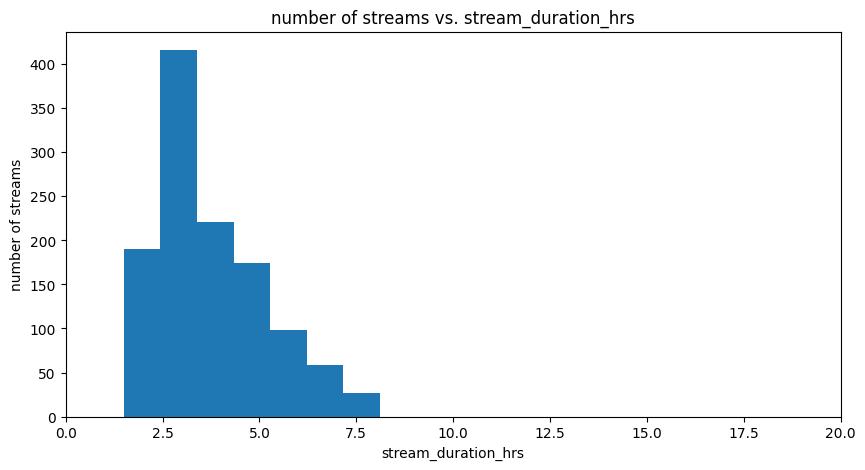

In [434]:
plt.figure(figsize=(10, 5))
plt.hist(df_streams["stream_duration_hrs"], bins=100)
plt.xlim(0, 20)
plt.xlabel("stream_duration_hrs")
plt.ylabel("number of streams")
plt.title("number of streams vs. stream_duration_hrs")

There is a peak in the shape of the data. The most anout a streams tend to last a little over 2.5 hours. I excluded the outliers which had high values in stream_duration_hrs so I could view the majority of thed ata in more detail.

Text(0.5, 1.0, 'number of streams vs. peak_viewers')

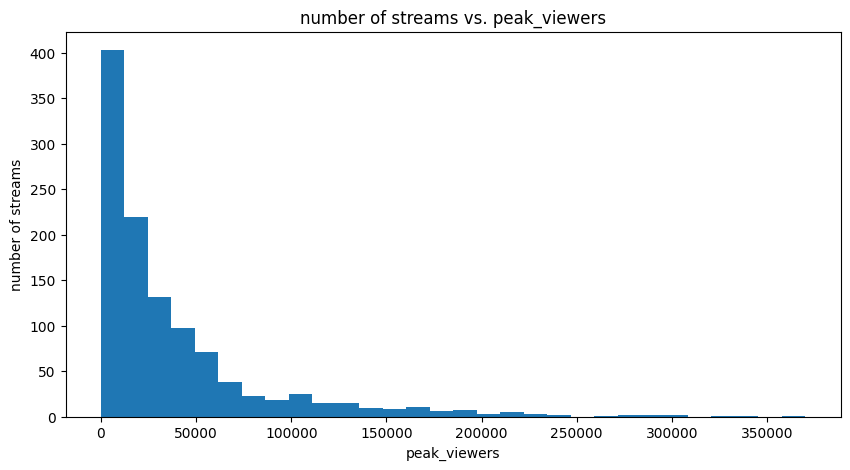

In [435]:
plt.figure(figsize=(10, 5))
plt.hist(df_streams["peak_viewers"], bins=30)
plt.xlabel("peak_viewers")
plt.ylabel("number of streams")
plt.title("number of streams vs. peak_viewers")

The shape of this plot decrease signicicantly as peak viewership increases.

#### Value Ranges

In [436]:
print(
    "Value Range of stream_duration_hrs: " +
    str(df_streams["stream_duration_hrs"].min()) +
    " to "  + str(df_streams["stream_duration_hrs"].max())
)

print(
    "Value Range of peak_viewers: " +
    str(df_streams["peak_viewers"].min()) +
    " to "  + str(df_streams["peak_viewers"].max())
)

Value Range of stream_duration_hrs: 1.5 to 96.0
Value Range of peak_viewers: -50.0 to 370165.0


stream_duration_hrs' data type of float is appropirate becuase there can be amounts that are fractions of hours. For peak_viewers, there are partial amounts of peak viewers and negative values that need to be cleaned.

#### Possible Categories

In [437]:
print("Possible Categories of category: " + str(df_streams["category"].unique()))
print("Possible Categories of title_has_hype_word: " + str(df_streams["title_has_hype_word"].unique()))
print("Possible Categories of was_raid: " + str(df_streams["was_raid"].unique()))

Possible Categories of category: <StringArray>
['Just Chatting', nan, 'FPS', 'MOBA', 'IRL', 'Creative', 'Sports']
Length: 7, dtype: str
Possible Categories of title_has_hype_word: [False  True]
Possible Categories of was_raid: [ True False]


category has a NaN category which need data cleaning. was_raid's categories are reversed compared to title_has_hype_word. was_raid's True value has a space in front of it. was_raid needs data cleaning.

### viewers.csv

*Columns*

- *viewer_id*: **Numerical**
    - the id of the viewer (the id starts with VWR) (string)
- *age_group*: **Categorical**
    - the age range of the viewer (string)
- *country*: **Categorical**
    - the country the viewer are located in (string)
- *account_age_days*: **Numerical**
    - how on the viewer account is in days (int)
- *subscription_tier*: **Categorical**
    - the subscription tier of the viewer (string)
- *preferred_category*: **Categorical**
    - the type of stream the viewer prefers (string)

In [438]:
df_viewers.head()

,viewer_id,age_group,country,account_age_days,subscription_tier,preferred_category
0,VWR00001,18-24,AR,355,free,IRL
1,VWR00002,25-34,CA,1670,free,Creative
2,VWR00003,35-44,US,1108,free,Just Chatting
3,VWR00004,45+,NaN,822,tier1,FPS
4,VWR00005,25-34,DE,2226,free,Just Chatting


Displayed to first 5 rows of sessions.csv in order to show the names of the columns and the types of their data.

#### Combining Categories

In [439]:
df_viewers["age_group_cleaned"] = df_viewers["age_group"]

mapping = {
    "18–24": "18-24",
    "18 to 24": "18-24",
    "25–34": "25-34",
    "25 to 34": "25-34",
    "35–44": "35-44",
    "35 to 44": "35-44",
}

df_viewers["age_group_cleaned"] = df_viewers["age_group_cleaned"].replace(mapping)

In [440]:
df_viewers["subscription_tier_cleaned"] = df_viewers["subscription_tier"]

mapping = {
    "TIER1": "tier1",
}

df_viewers["subscription_tier_cleaned"] = df_viewers["subscription_tier_cleaned"].replace(mapping)

There were several same type categories that were written differently. I combined them into a new column.

#### Shape of the Data

Text(0.5, 1.0, 'number of viewers vs. account_age_days')

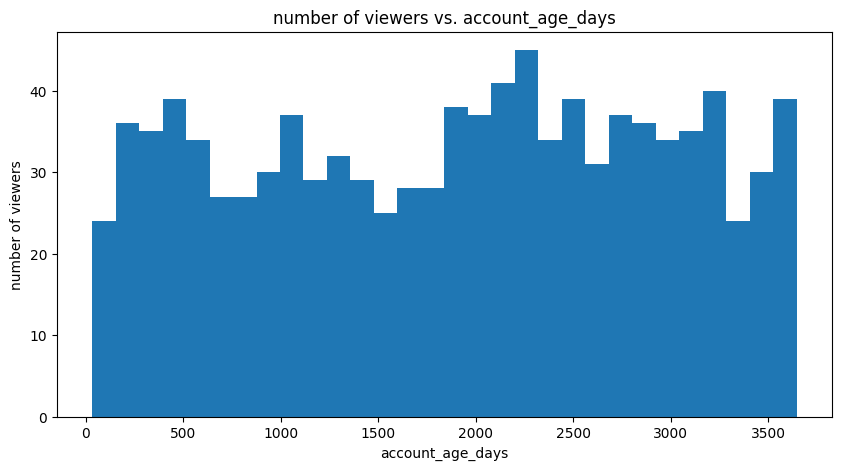

In [441]:
plt.figure(figsize=(10, 5))
plt.hist(df_viewers["account_age_days"], bins=30)
plt.xlabel("account_age_days")
plt.ylabel("number of viewers")
plt.title("number of viewers vs. account_age_days")

There is no shape in the data. There are a diverse and spread out number of viewers who have new and old accounts.

Text(0.5, 1.0, 'number of viewers vs. age_group_cleaned')

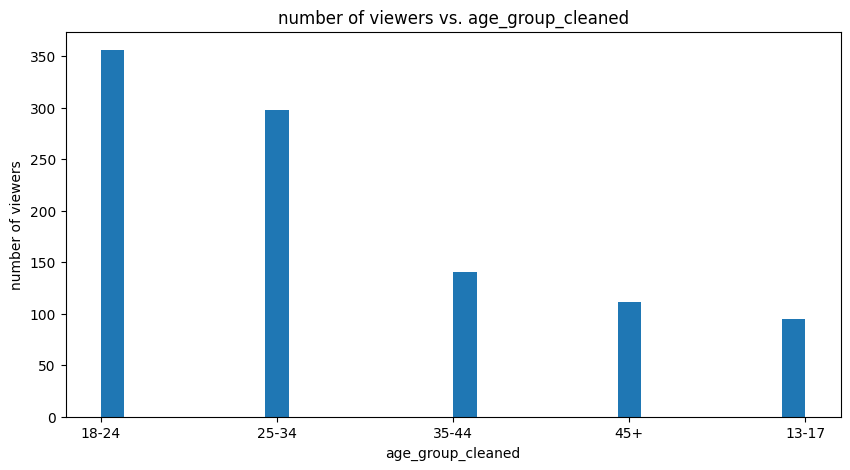

In [442]:
plt.figure(figsize=(10, 5))
plt.hist(df_viewers["age_group_cleaned"], bins=30)
plt.xlabel("age_group_cleaned")
plt.ylabel("number of viewers")
plt.title("number of viewers vs. age_group_cleaned")

Most of the viewers are ages 18-24 and 25-34.

#### Value Ranges

In [443]:
print(
    "Value Range of account_age_days: " +
    str(df_viewers["account_age_days"].min()) +
    " to "  + str(df_viewers["account_age_days"].max())
)

Value Range of account_age_days: 33 to 3645


The account_age_days value range makes sense.

#### Possible Categories

In [444]:
print("Possible Categories of age_group: " + str(df_viewers["age_group"].unique()))
print("Possible Categories of age_group_cleaned: " + str(df_viewers["age_group_cleaned"].unique()))
print("Possible Categories of country: " + str(df_viewers["country"].unique()))
print("Possible Categories of subscription_tier: " + str(df_viewers["subscription_tier"].unique()))
print("Possible Categories of subscription_tier_cleaned: " + str(df_viewers["subscription_tier_cleaned"].unique()))
print("Possible Categories of preferred_category: " + str(df_viewers["preferred_category"].unique()))

Possible Categories of age_group: <StringArray>
[   '18-24',    '25-34',    '35-44',      '45+',    '13-17',    '18–24',
    '25–34', '35 to 44', '18 to 24', '25 to 34',    '35–44']
Length: 11, dtype: str
Possible Categories of age_group_cleaned: <StringArray>
['18-24', '25-34', '35-44', '45+', '13-17']
Length: 5, dtype: str
Possible Categories of country: <StringArray>
[   'AR',    'CA',    'US',     nan,    'DE',    'ES', 'other',    'FR',
    'GB',    'SE',    'BR',    'IT',    'RU',    'MX',    'PL',    'NL',
    'JP',    'IN',    'KR',    'AU',    'TR']
Length: 21, dtype: str
Possible Categories of subscription_tier: <StringArray>
[      'free',      'tier1',      'tier2',      'tier3', 'free trial',
    'premium',       'none',      'tier4',      'TIER1']
Length: 9, dtype: str
Possible Categories of subscription_tier_cleaned: <StringArray>
['free', 'tier1', 'tier2', 'tier3', 'free trial', 'premium', 'none', 'tier4']
Length: 8, dtype: str
Possible Categories of preferred_category:

For age_group, there are categories of 18-24, 25-34, and 35-44 written is in different ways and needs to be cleaned. subscription_tier also needs to be clean because of two ways tier1 is written.

### Task 1 Summary Report

The relationships of each .csv files to the other ones
- sessions point to viewers, streamer, and streams
- streamers do not point to anything
- streams point to streamers
- viewers do not point to anything

There is data cleanup to be done
- NaN values need to be removed
- there are some negative values that do not make sense

# Task 2: Data Cleaning, Diagnostics, and Corrections

Identify and resolve issues in the dataset. These can be of different kinds, such as:
- Look for duplicates or implausible values (e.g., users with negative followers, invalid age groups). Thoroughly document your exploration of the data. Decide whether these are outliers or the result of a systemic problem. If the latter, resolve the problem here; if they are outliers, we will address those later.  
- Define at least three heuristics (common-sense rules) to flag unusual entries (e.g., someone watching dozens of streams per day). Discuss whether what you found are errors or artifacts.  

I will repeat the instructions here, but this is expected for each task: each code cell should focus on a specific analysis. You should run the code, and in the markdown below each code cell and its result, provide a detailed interpretation of what you have uncovered in that step. After completing the analyses, summarize the key findings in the indicated summary report cell below.


#### Checking id Columns for NaN Values

In [445]:
dfs = {
    "df_sessions": df_sessions,
    "df_streamers": df_streamers,
    "df_streams": df_streams,
    "df_viewers": df_viewers,
}

id_columns = ["session_id", "viewer_id", "streamer_id", "stream_id"]

for df_name, df in dfs.items():
    print(f"--- {df_name} ---")

    available_cols = [col for col in id_columns if col in df.columns]

    if not available_cols:
        print("None of the columns exist in this DataFrame.")
        continue

    null_counts = df[available_cols].isna().sum()

    print(null_counts)

--- df_sessions ---
session_id      0
viewer_id       0
streamer_id    60
stream_id       0
dtype: int64
--- df_streamers ---
streamer_id    0
dtype: int64
--- df_streams ---
streamer_id    0
stream_id      0
dtype: int64
--- df_viewers ---
viewer_id    0
dtype: int64


There are 60 null values in streamer_id column. These rows containing these null values will be deleted from the DataFrame.

### sessions.csv

In [446]:
df_sessions = df_sessions.dropna(subset=["streamer_id"])
print("Number of streamer_id NaN values: " + str(df_sessions["streamer_id"].isna().sum()))


Number of streamer_id NaN values: 0


There are no NaN values in the column streamer_id.

In [447]:
df_sessions = df_sessions[df_sessions["duration_mins"] >= 0]

df_sessions["started_at"] = pd.to_datetime(df_sessions["started_at"])
df_sessions["ended_at"] = pd.to_datetime(df_sessions["ended_at"])

calculated_mins = (df_sessions["ended_at"] - df_sessions["started_at"]).dt.total_seconds() / 60
is_valid_duration = (calculated_mins > 0) & (calculated_mins == df_sessions["duration_mins"])
df_sessions = df_sessions[is_valid_duration].reset_index(drop=True)

check_mins = (df_sessions["ended_at"] - df_sessions["started_at"]).dt.total_seconds() / 60
incorrect_rows = df_sessions[(check_mins <= 0) | (check_mins != df_sessions["duration_mins"])]

if incorrect_rows.empty:
    print("0 incorrect values found.")
else:
    print(f"Found {len(incorrect_rows)} incorrect rows.")
    print(incorrect_rows)

0 incorrect values found.


Any rows with duration_mins values that were negative, the difference between started_at and ended_at were negative, and if this difference was not the same as duration_mins were deleted.

### streamers.csv

In [448]:
df_streamers["total_followers_cleaned"] = df_streamers["total_followers"].map(lambda i: 0 if i < 0 or pd.isna(i) else i)
print(
    "Value Range of total_followers: " +
    str(df_streamers["total_followers"].min()) +
    " to "  + str(df_streamers["total_followers"].max())
)

print(
    "Value Range of total_followers_cleaned: " +
    str(df_streamers["total_followers_cleaned"].min()) +
    " to "  + str(df_streamers["total_followers_cleaned"].max())
)

Value Range of total_followers: -46964 to 18700000
Value Range of total_followers_cleaned: 0 to 18700000


I have converted all the negative and NaN values of total_followers to 0 because a streamer can not have negative or NaN followers.

In [449]:
df_streamers["language_cleaned"] = df_streamers["language"].fillna("other")
print("Possible Categories of language: " + str(df_streamers["language"].unique()))
print("Possible Categories of language_cleaned: " + str(df_streamers["language_cleaned"].unique()))

Possible Categories of language: <StringArray>
['English', 'Spanish', nan, 'Korean', 'Portuguese']
Length: 5, dtype: str
Possible Categories of language_cleaned: <StringArray>
['English', 'Spanish', 'other', 'Korean', 'Portuguese']
Length: 5, dtype: str


Converting NaN values to other for the language_cleaned column makes more sense because the streamer with NaN language values could be speaking a different language that is not listed in this column.

### streams.csv

In [450]:
df_streams["peak_viewers_cleaned"] = df_streams["peak_viewers"].map(lambda i: 0 if i < 0 or pd.isna(i) else i)
print(
    "Value Range of peak_viewers: " +
    str(df_streams["peak_viewers"].min()) +
    " to "  + str(df_streams["peak_viewers"].max())
)

print(
    "Value Range of peak_viewers_cleaned: " +
    str(df_streams["peak_viewers_cleaned"].min()) +
    " to "  + str(df_streams["peak_viewers_cleaned"].max())
)

Value Range of peak_viewers: -50.0 to 370165.0
Value Range of peak_viewers_cleaned: 0.0 to 370165.0


I have converted all the negative and NaN values of peak_viewers to 0 because a stream can not have negative or NaN peak views.

In [451]:
df_streams["category_cleaned"] = df_streams["category"].fillna("other")
print("Possible Categories of category: " + str(df_streams["category"].unique()))
print("Possible Categories of category_cleaned: " + str(df_streams["category_cleaned"].unique()))

Possible Categories of category: <StringArray>
['Just Chatting', nan, 'FPS', 'MOBA', 'IRL', 'Creative', 'Sports']
Length: 7, dtype: str
Possible Categories of category_cleaned: <StringArray>
['Just Chatting', 'other', 'FPS', 'MOBA', 'IRL', 'Creative', 'Sports']
Length: 7, dtype: str


Converting NaN values to other for the category_cleaned column makes more sense because streams with NaN language values could be other categories that are not listed in this column.

In [452]:
df_streams = df_streams[df_streams["stream_duration_hrs"] >= 0]

df_streams["started_at"] = pd.to_datetime(df_streams["started_at"])
df_streams["ended_at"] = pd.to_datetime(df_streams["ended_at"])

calculated_hrs = (df_streams["ended_at"] - df_streams["started_at"]).dt.total_seconds() / 3600
is_valid_duration = (calculated_hrs > 0) & (calculated_hrs == df_streams["stream_duration_hrs"])
df_streams = df_streams[is_valid_duration].reset_index(drop=True)

check_hrs = (df_streams["ended_at"] - df_streams["started_at"]).dt.total_seconds() / 3600
incorrect_rows = df_streams[(check_hrs <= 0) | (check_hrs != df_streams["stream_duration_hrs"])]

if incorrect_rows.empty:
    print("0 incorrect values found.")
else:
    print(f"Found {len(incorrect_rows)} incorrect rows.")
    print(incorrect_rows)

0 incorrect values found.


Any rows with stream_duration_hrs values that were negative, the difference between started_at and ended_at were negative, and if this difference was not the same as stream_duration_hrs were deleted.

### viewers.csv

In [453]:
df_viewers["country_cleaned"] = df_viewers["country"].fillna("other")
print("Possible Categories of country: " + str(df_viewers["country"].unique()))
print("Possible Categories of country_cleaned: " + str(df_viewers["country_cleaned"].unique()))

Possible Categories of country: <StringArray>
[   'AR',    'CA',    'US',     nan,    'DE',    'ES', 'other',    'FR',
    'GB',    'SE',    'BR',    'IT',    'RU',    'MX',    'PL',    'NL',
    'JP',    'IN',    'KR',    'AU',    'TR']
Length: 21, dtype: str
Possible Categories of country_cleaned: <StringArray>
[   'AR',    'CA',    'US', 'other',    'DE',    'ES',    'FR',    'GB',
    'SE',    'BR',    'IT',    'RU',    'MX',    'PL',    'NL',    'JP',
    'IN',    'KR',    'AU',    'TR']
Length: 20, dtype: str


Converting NaN values to other for the country_cleaned column makes more sense because the viewers with NaN language values could be in a differnt country that is not listed in this column.

### Heuristics

- streamer ids that are NaN
    - this is an error because the streamer needs an id to be identified
- duration of sessions and streams were negative
    - this is an error because it is miscalculated
- the difference between start and end times of sessions and streams were negative
    - this is an error because it is miscalculated
    - the difference was not the same as duration_mins
        - this is an error because it is miscalculated
- a streamer having negative total followers
    - this is an artifact because it does not make sense to have a quantity of something that is negative
- a streamer having NaN for a language
    - maybe be an arifact for the cases where the language is unknown
- a stream that has negative peak viewers
    - this is an artifact becaise it does not make sense to have a quanityt of somethings that is negative
- a stream that has NaN for a category
    - this is an arfitact because the stream can be another category not listed in the data
- viewers that have NaN country values
    - this is an artifact because the viewers can be in a country that is not listed in the data

### Task 2 summary report

Throught the four csv files, certain rows needed to be modified or deleted
- some rows needed to be deleted beucase of NaNs and miscalutations
- certain negative values were changed to 0
- NaNs values in categorical columns were changed to "other"

# Task 3: Descriptive Statistics and Visualizations

- Create summary statistics and visualizations to understand user characteristics  
- Create summary statistics for streams data overall, and summaries by age group, account tire, or peak viewers  
- Visualize the distribution of streams durations, popular categories,   
- Show category-specific information and compare streamers based on categories  

### sessions.csv

In [454]:
print("duration_mins stats: \n" +
      "median " + str(df_sessions["duration_mins"].median()) + "\n" +
      str(df_sessions["duration_mins"].describe()),"\n"
)
print("chat_messages_sent stats: \n" +
      "median " + str(df_sessions["chat_messages_sent"].median()) + "\n" +
      str(df_sessions["chat_messages_sent"].describe()),"\n"
)
print("bits_cheered stats: \n" +
      "median " + str(df_sessions["bits_cheered"].median()) + "\n" +
      str(df_sessions["bits_cheered"].describe()),"\n"
)

duration_mins stats: 
median 39.0
count    22644.000000
mean        59.255211
std         60.401259
min          2.000000
25%         16.000000
50%         39.000000
75%         83.000000
max        443.000000
Name: duration_mins, dtype: float64 

chat_messages_sent stats: 
median 1.0
count    22644.000000
mean         4.886725
std         10.025623
min          0.000000
25%          0.000000
50%          1.000000
75%          5.000000
max        220.000000
Name: chat_messages_sent, dtype: float64 

bits_cheered stats: 
median 0.0
count    22644.000000
mean       397.445548
std       1570.153385
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      10000.000000
Name: bits_cheered, dtype: float64 



Text(0.5, 1.0, 'duration_mins Boxplot')

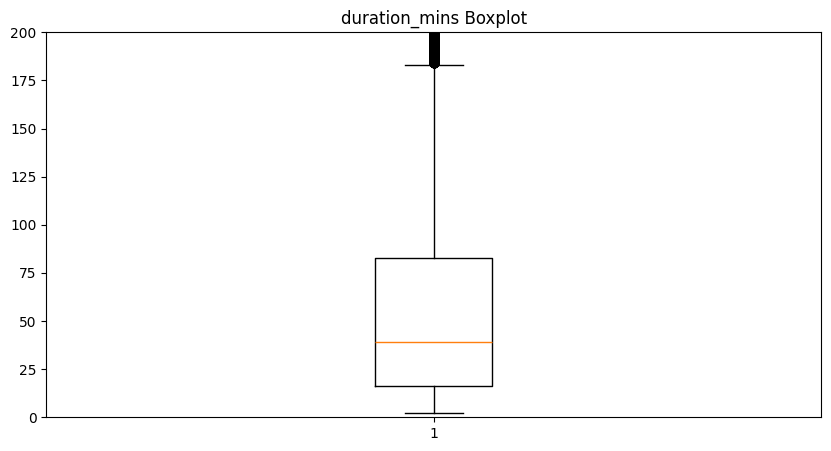

In [455]:
plt.figure(figsize=(10, 5))
plt.boxplot(df_sessions["duration_mins"])
plt.ylim(0, 200)
plt.title("duration_mins Boxplot")

More of the data is skewed towards the bottom of the box plot. There are a lot fo outliers towards the top and I zoomed in of the boxplot.

Text(0.5, 1.0, 'chat_messages_sent Boxplot')

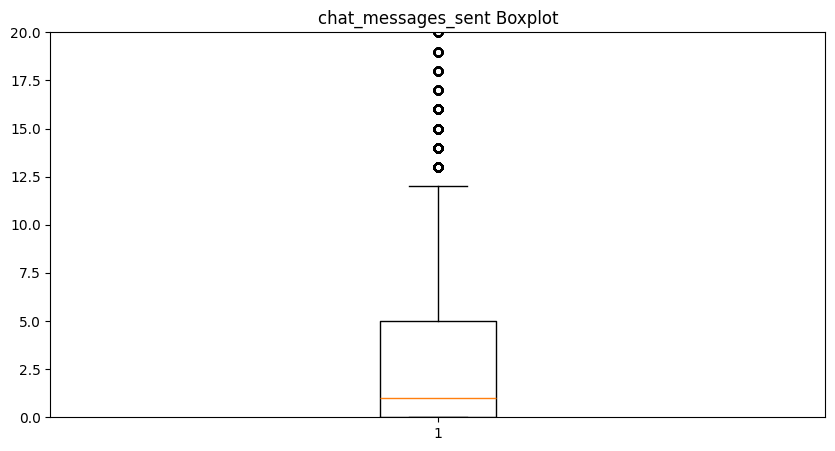

In [456]:
plt.figure(figsize=(10, 5))
plt.boxplot(df_sessions["chat_messages_sent"])
plt.ylim(0, 20)
plt.title("chat_messages_sent Boxplot")

The boxplot is more skewed towards 0 compared to the previous plot. Each point at the top is an outlier.

Text(0.5, 1.0, 'bits_cheered Boxplot')

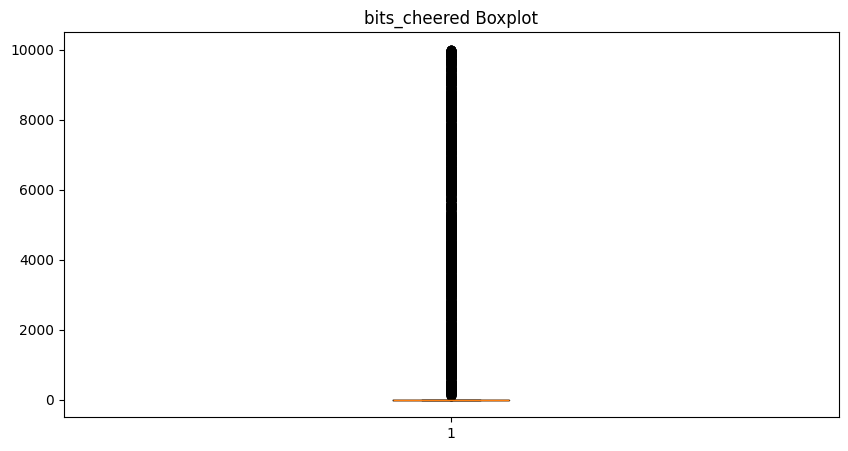

In [490]:
plt.figure(figsize=(10, 5))
plt.boxplot(df_sessions["bits_cheered"])
plt.title("bits_cheered Boxplot")

Most of the data is at 0 except for the outliers.

In [458]:
print(df_sessions["followed_during"].value_counts(), "\n")
print(df_sessions["subscribed_during"].value_counts())

followed_during
False    21488
True      1156
Name: count, dtype: int64 

subscribed_during
False    22206
True       438
Name: count, dtype: int64


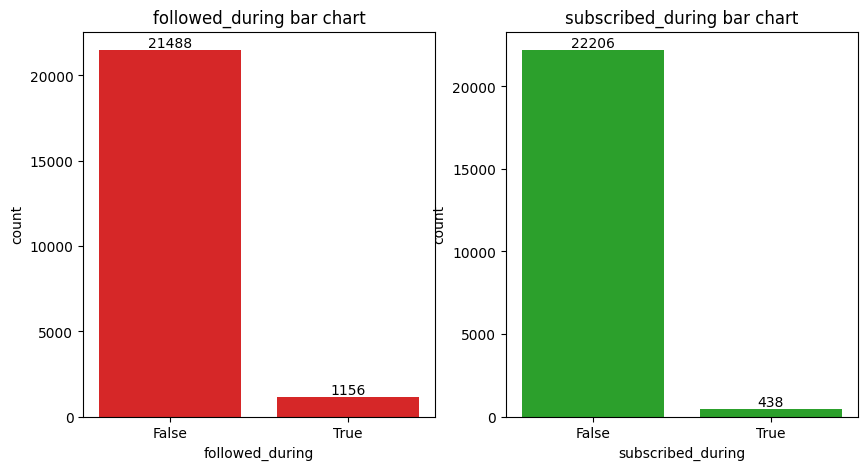

In [459]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

fd_counts = df_sessions["followed_during"].value_counts()
fd_bars = ax1.bar(fd_counts.index.astype(str), fd_counts.values, color="tab:red")

ax1.bar_label(fd_bars)
ax1.set_title("followed_during bar chart")
ax1.set_xlabel("followed_during")
ax1.set_ylabel("count")

sd_counts = df_sessions["subscribed_during"].value_counts()
sd_bars = ax2.bar(sd_counts.index.astype(str), sd_counts.values, color="tab:green")

ax2.bar_label(sd_bars)
ax2.set_title("subscribed_during bar chart")
ax2.set_xlabel("subscribed_during")
ax2.set_ylabel("count")

plt.show()

For both plots, most of the sessions do not have follows or subscriptions.

### streamers.csv

In [460]:
print("total_followers_cleaned stats: \n" +
      "median " + str(df_streamers["total_followers_cleaned"].median()) + "\n" +
      str(df_streamers["total_followers_cleaned"].describe()),"\n"
)
print("avg_concurrent_viewers stats: \n" +
      "median " + str(df_streamers["avg_concurrent_viewers"].median()) + "\n" +
      str(df_streamers["avg_concurrent_viewers"].describe()),"\n"
)

total_followers_cleaned stats: 
median 2000000.0
count    7.600000e+01
mean     3.303026e+06
std      3.791873e+06
min      0.000000e+00
25%      7.800000e+05
50%      2.000000e+06
75%      3.875000e+06
max      1.870000e+07
Name: total_followers_cleaned, dtype: float64 

avg_concurrent_viewers stats: 
median 14762.5
count        76.000000
mean      31227.986842
std       38307.223652
min         634.000000
25%        6633.250000
50%       14762.500000
75%       36840.750000
max      156401.000000
Name: avg_concurrent_viewers, dtype: float64 



Text(0.5, 1.0, 'total_followers_cleaned Boxplot')

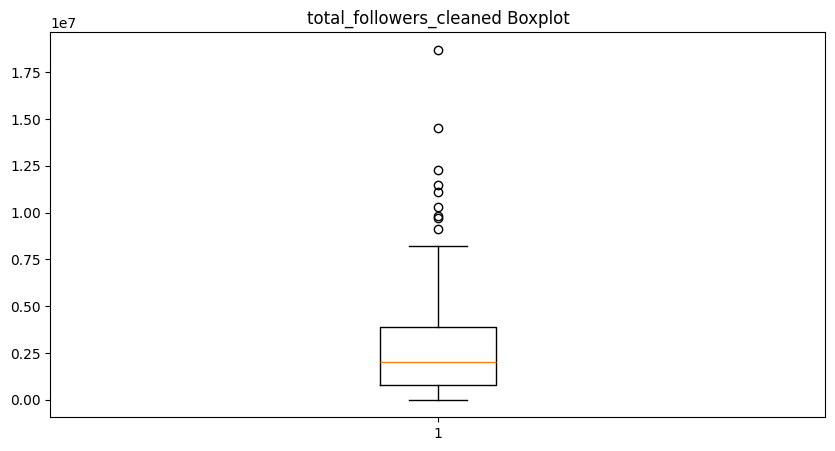

In [461]:
plt.figure(figsize=(10, 5))
plt.boxplot(df_streamers["total_followers_cleaned"])
plt.title("total_followers_cleaned Boxplot")

This boxplot of skewed to the bottom. Most streamers do not have a lot fo followers compared to the outliers.

Text(0.5, 1.0, 'avg_concurrent_viewers Boxplot')

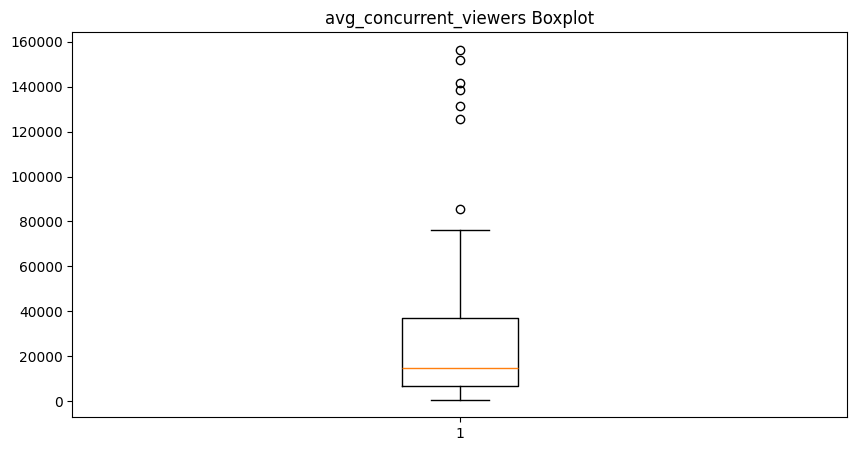

In [462]:
plt.figure(figsize=(10, 5))
plt.boxplot(df_streamers["avg_concurrent_viewers"])
plt.title("avg_concurrent_viewers Boxplot")

This boxplot is skewed towards the bottom and only have outliers at the top half of the plot.

In [463]:
print(df_streamers["category"].value_counts(), "\n")
print(df_streamers["language"].value_counts(), "\n")
print(df_streamers["partner_status"].value_counts())

category
Just Chatting    18
FPS              13
Creative         13
MOBA             12
Sports           11
IRL               9
Name: count, dtype: int64 

language
English       61
Spanish        5
Korean         1
Portuguese     1
Name: count, dtype: int64 

partner_status
True     66
False    10
Name: count, dtype: int64


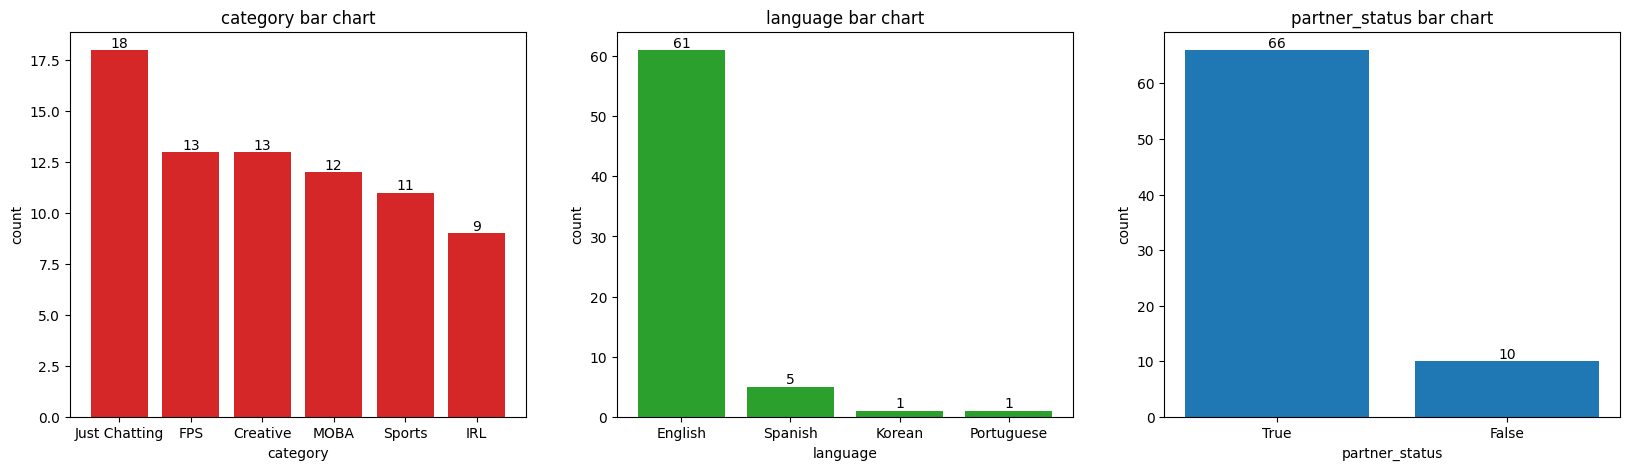

In [464]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))

str_c_counts = df_streamers["category"].value_counts()
str_c_bars = ax1.bar(str_c_counts.index.astype(str), str_c_counts.values, color="tab:red")

ax1.bar_label(str_c_bars)
ax1.set_title("category bar chart")
ax1.set_xlabel("category")
ax1.set_ylabel("count")

l_counts = df_streamers["language"].value_counts()
l_bars = ax2.bar(l_counts.index.astype(str), l_counts.values, color="tab:green")

ax2.bar_label(l_bars)
ax2.set_title("language bar chart")
ax2.set_xlabel("language")
ax2.set_ylabel("count")

ps_counts = df_streamers["partner_status"].value_counts()
ps_bars = ax3.bar(ps_counts.index.astype(str), ps_counts.values, color="tab:blue")

ax3.bar_label(ps_bars)
ax3.set_title("partner_status bar chart")
ax3.set_xlabel("partner_status")
ax3.set_ylabel("count")

plt.show()

streaners that do streams about Just Chatting, speak English, and have a partner is the majority of the data.

### streams.csv

In [465]:
print("stream_duration_hrs stats: \n" +
      "median " + str(df_streams["stream_duration_hrs"].median()) + "\n" +
      str(df_streams["stream_duration_hrs"].describe()),"\n"
)
print("peak_viewers_cleaned stats: \n" +
      "median " + str(df_streams["peak_viewers_cleaned"].median()) + "\n" +
      str(df_streams["peak_viewers_cleaned"].describe()),"\n"
)

stream_duration_hrs stats: 
median 3.0
count    1184.000000
mean        3.771537
std         1.596555
min         1.500000
25%         2.500000
50%         3.000000
75%         5.000000
max         8.000000
Name: stream_duration_hrs, dtype: float64 

peak_viewers_cleaned stats: 
median 17228.5
count      1184.000000
mean      35686.377534
std       49548.068467
min           0.000000
25%        5609.750000
50%       17228.500000
75%       44104.750000
max      370165.000000
Name: peak_viewers_cleaned, dtype: float64 



Text(0.5, 1.0, 'stream_duration_hrs Boxplot')

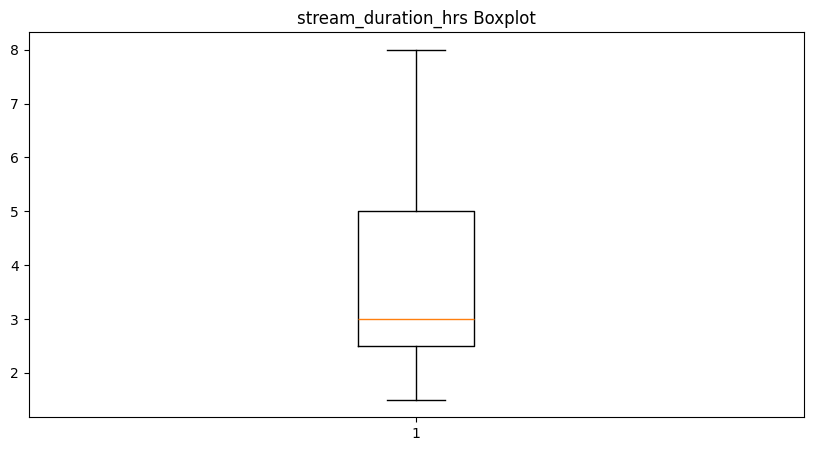

In [466]:
plt.figure(figsize=(10, 5))
plt.boxplot(df_streams["stream_duration_hrs"])
plt.title("stream_duration_hrs Boxplot")

The boxplot doe snot have any outliers and is skewed towards the bottom.

Text(0.5, 1.0, 'peak_viewers_cleaned Boxplot')

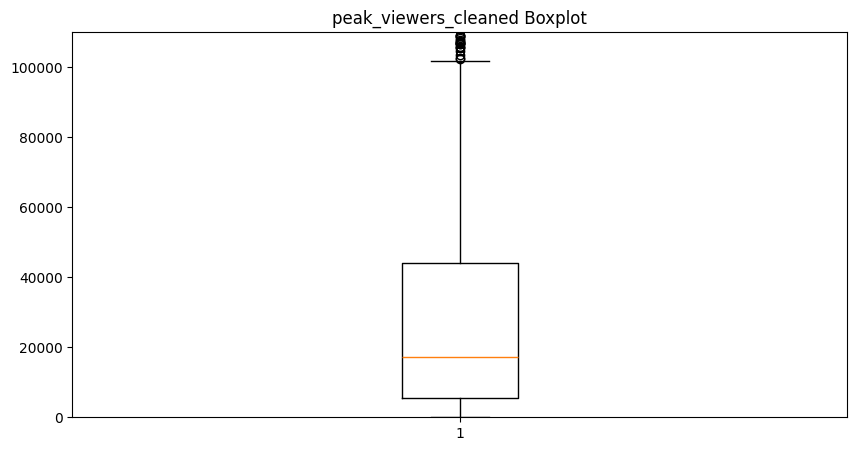

In [467]:
plt.figure(figsize=(10, 5))
plt.boxplot(df_streams["peak_viewers_cleaned"])
plt.ylim(0, 110000)
plt.title("peak_viewers_cleaned Boxplot")

This plot has a lot of outliers and the bottom whisker is at 0.

In [468]:
print(df_streams["category"].value_counts(), "\n")
print(df_streams["title_has_hype_word"].value_counts(), "\n")
print(df_streams["was_raid"].value_counts())

category
Just Chatting    273
FPS              201
Creative         190
Sports           176
MOBA             169
IRL              125
Name: count, dtype: int64 

title_has_hype_word
False    842
True     342
Name: count, dtype: int64 

was_raid
False    1019
True      165
Name: count, dtype: int64


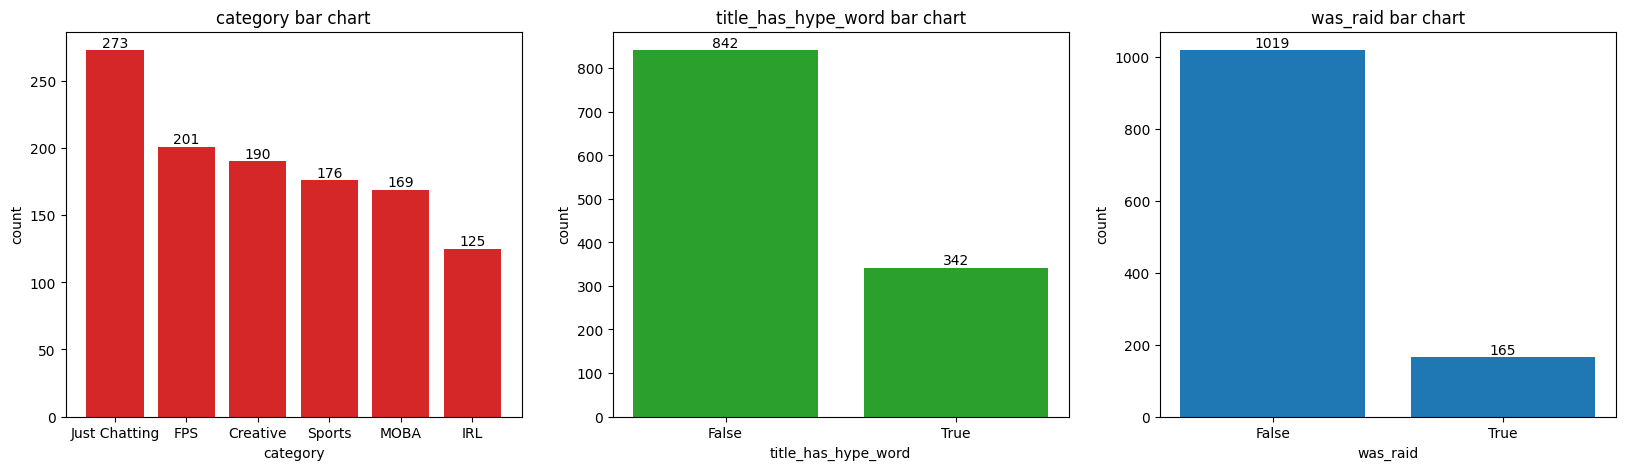

In [469]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))

st_c_counts = df_streams["category"].value_counts()
st_c_bars = ax1.bar(st_c_counts.index.astype(str), st_c_counts.values, color="tab:red")

ax1.bar_label(st_c_bars)
ax1.set_title("category bar chart")
ax1.set_xlabel("category")
ax1.set_ylabel("count")

thhw_counts = df_streams["title_has_hype_word"].value_counts()
thhw_bars = ax2.bar(thhw_counts.index.astype(str), thhw_counts.values, color="tab:green")

ax2.bar_label(thhw_bars)
ax2.set_title("title_has_hype_word bar chart")
ax2.set_xlabel("title_has_hype_word")
ax2.set_ylabel("count")

wr_counts = df_streams["was_raid"].value_counts()
wr_bars = ax3.bar(wr_counts.index.astype(str), wr_counts.values, color="tab:blue")

ax3.bar_label(wr_bars)
ax3.set_title("was_raid bar chart")
ax3.set_xlabel("was_raid")
ax3.set_ylabel("count")

plt.show()

Most streams are about Just Chatting, do not have the word hype in its names, and were not raided.

### viewers.csv

In [470]:
print("account_age_days stats: \n" +
      "median " + str(df_viewers["account_age_days"].median()) + "\n" +
      str(df_viewers["account_age_days"].describe()),"\n"
)

account_age_days stats: 
median 1966.5
count    1000.000000
mean     1881.119000
std      1036.144656
min        33.000000
25%       984.500000
50%      1966.500000
75%      2761.250000
max      3645.000000
Name: account_age_days, dtype: float64 



Text(0.5, 1.0, 'account_age_days Boxplot')

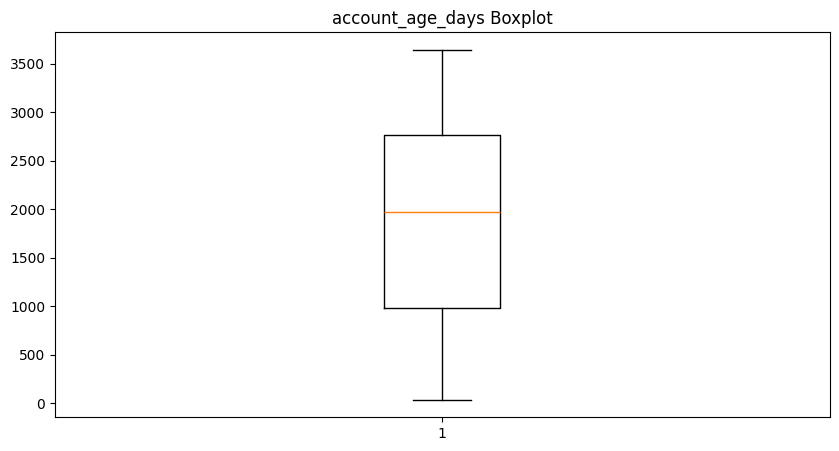

In [471]:
plt.figure(figsize=(10, 5))
plt.boxplot(df_viewers["account_age_days"])
plt.title("account_age_days Boxplot")

This boxplot is skewed towards the top. A lot of account are old in days.

In [472]:
print(df_viewers["age_group_cleaned"].value_counts(), "\n")
print(df_viewers["country"].value_counts(), "\n")
print(df_viewers["subscription_tier_cleaned"].value_counts(), "\n")
print(df_viewers["preferred_category"].value_counts())

age_group_cleaned
18-24    356
25-34    298
35-44    140
45+      111
13-17     95
Name: count, dtype: int64 

country
US       264
GB        82
CA        66
DE        53
BR        51
FR        47
KR        44
MX        40
other     38
JP        33
AU        31
IT        28
NL        22
ES        21
RU        20
AR        19
SE        19
IN        18
PL        17
TR         7
Name: count, dtype: int64 

subscription_tier_cleaned
free          578
tier1         248
tier2         100
tier3          49
premium        10
none            7
free trial      4
tier4           4
Name: count, dtype: int64 

preferred_category
Just Chatting    269
FPS              230
MOBA             161
IRL              120
Creative         117
Sports           103
Name: count, dtype: int64


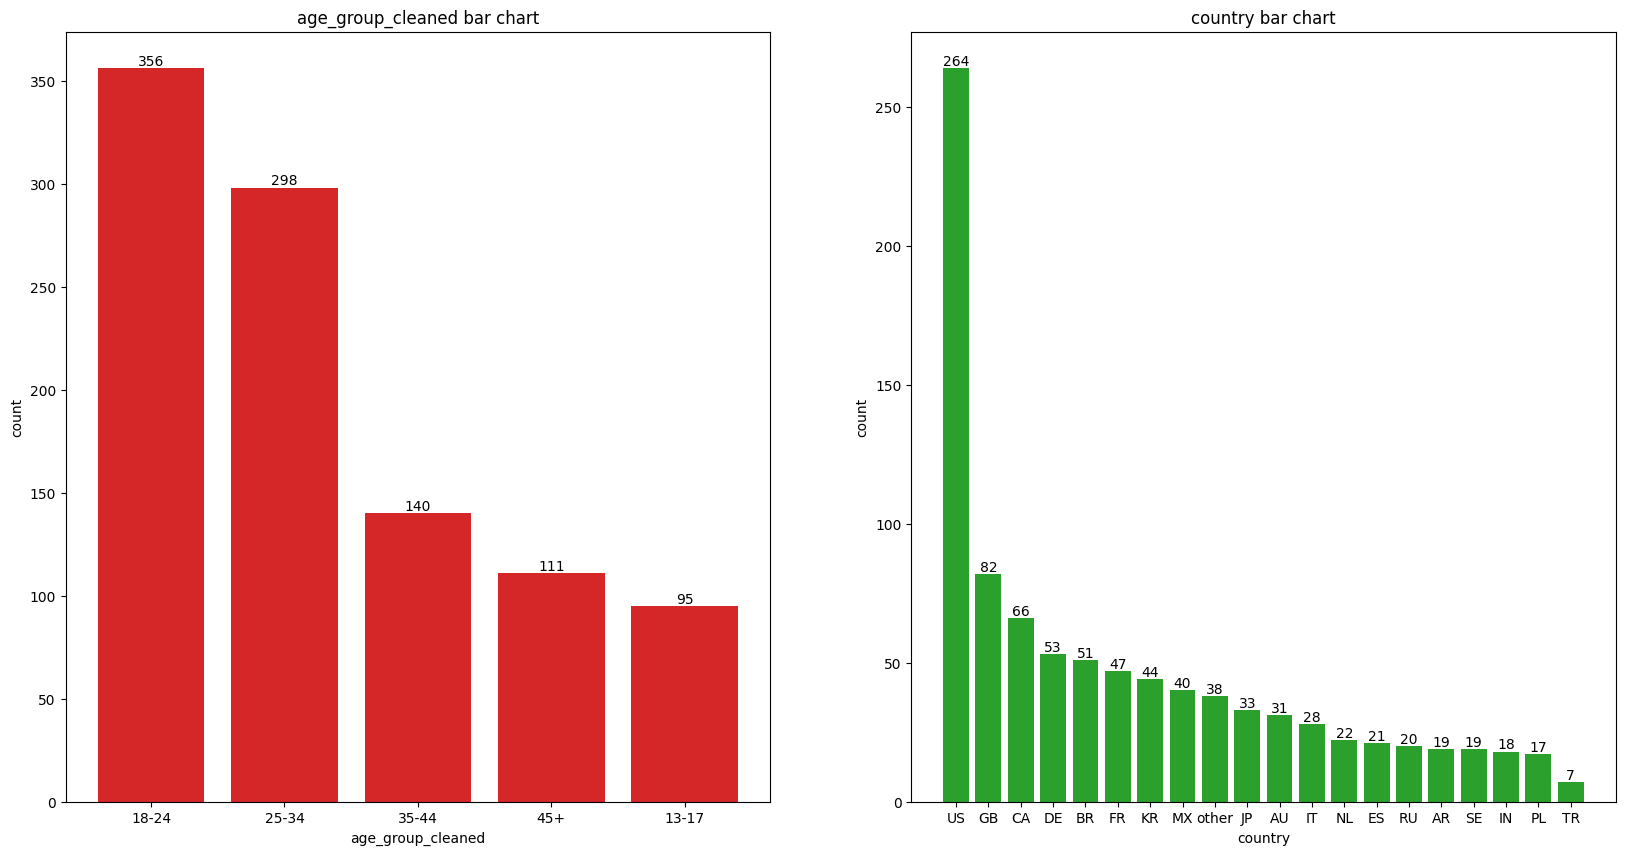

In [473]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

ag_counts = df_viewers["age_group_cleaned"].value_counts()
ag_bars = ax1.bar(ag_counts.index.astype(str), ag_counts.values, color="tab:red")

ax1.bar_label(ag_bars)
ax1.set_title("age_group_cleaned bar chart")
ax1.set_xlabel("age_group_cleaned")
ax1.set_ylabel("count")

v_c_counts = df_viewers["country"].value_counts()
v_c_bars = ax2.bar(v_c_counts.index.astype(str), v_c_counts.values, color="tab:green")

ax2.bar_label(v_c_bars)
ax2.set_title("country bar chart")
ax2.set_xlabel("country")
ax2.set_ylabel("count")

plt.show()

Most Twitch viewers are 18-24 and are in the US.

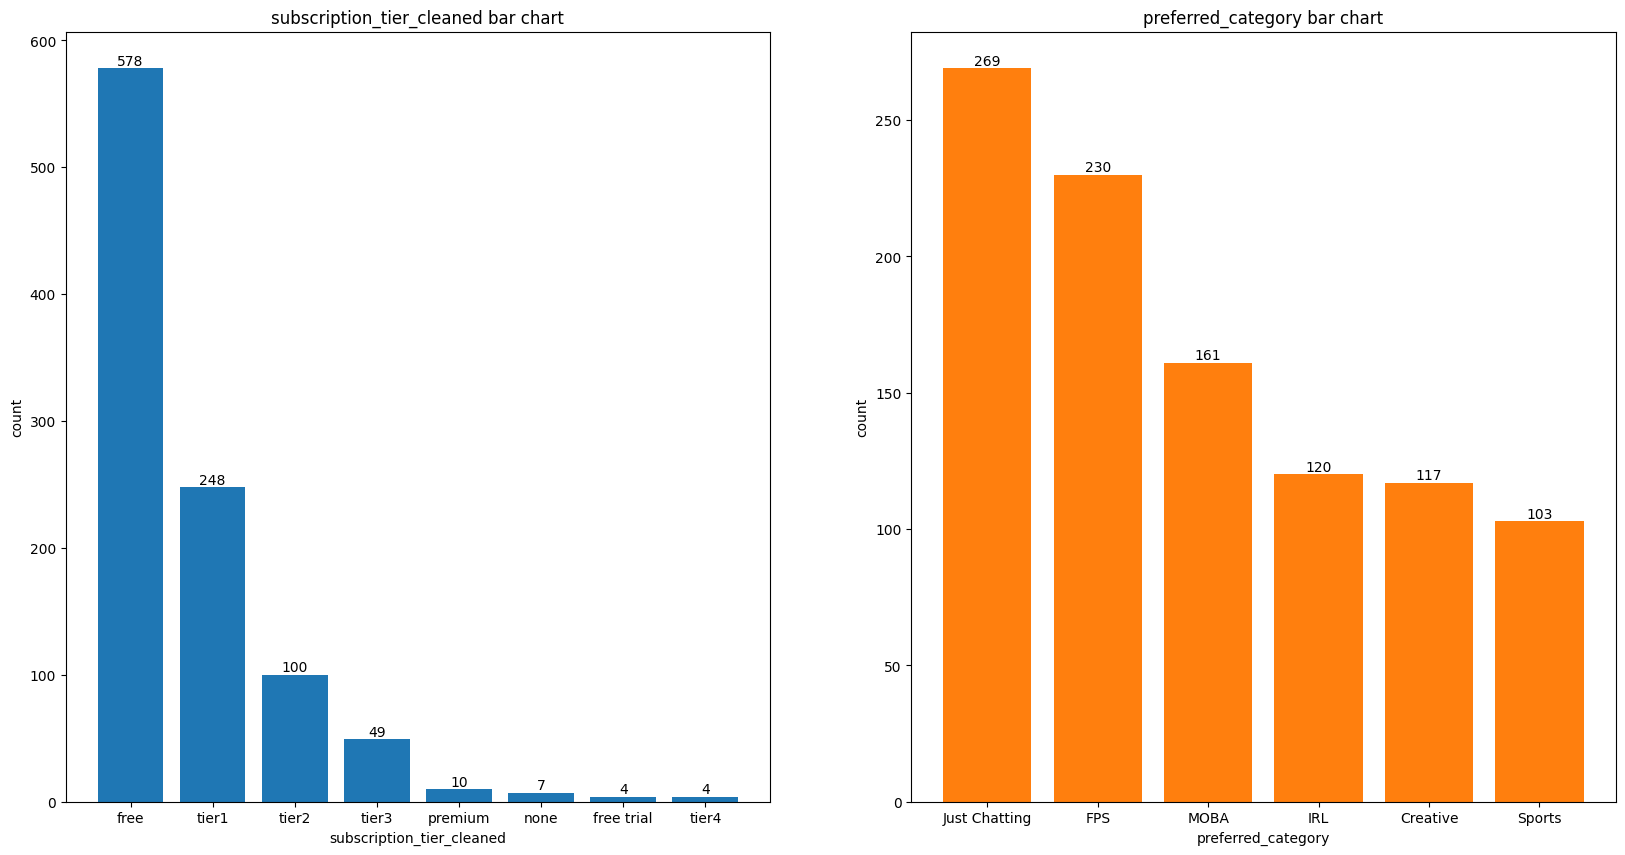

In [474]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

stc_counts = df_viewers["subscription_tier_cleaned"].value_counts()
stc_bars = ax1.bar(stc_counts.index.astype(str), stc_counts.values, color="tab:blue")

ax1.bar_label(stc_bars)
ax1.set_title("subscription_tier_cleaned bar chart")
ax1.set_xlabel("subscription_tier_cleaned")
ax1.set_ylabel("count")

pc_counts = df_viewers["preferred_category"].value_counts()
pc_bars = ax2.bar(pc_counts.index.astype(str), pc_counts.values, color="tab:orange")

ax2.bar_label(pc_bars)
ax2.set_title("preferred_category bar chart")
ax2.set_xlabel("preferred_category")
ax2.set_ylabel("count")

plt.show()

Most viewers have a free tier and have a preferred category of Just Chatting.

### streams.csv Overall Data

In [475]:
print(df_streams["stream_duration_hrs"].describe(), "\n")
print(df_streams["peak_viewers_cleaned"].describe())

count    1184.000000
mean        3.771537
std         1.596555
min         1.500000
25%         2.500000
50%         3.000000
75%         5.000000
max         8.000000
Name: stream_duration_hrs, dtype: float64 

count      1184.000000
mean      35686.377534
std       49548.068467
min           0.000000
25%        5609.750000
50%       17228.500000
75%       44104.750000
max      370165.000000
Name: peak_viewers_cleaned, dtype: float64


### Summary Statistics by age_group

In [498]:
df_stream_viewer = (
    df_sessions
    .merge(df_streams[["stream_id", "stream_duration_hrs", "peak_viewers_cleaned"]], on="stream_id")
    .merge(df_viewers[["viewer_id", "age_group_cleaned"]], on="viewer_id")
)

df_stream_viewer.groupby("age_group_cleaned")[["duration_mins", "chat_messages_sent", "bits_cheered"]].describe()

duration_mins                                               \
                          count       mean        std  min   25%   50%   75%   
age_group_cleaned                                                              
13-17                    2067.0  58.554427  59.211717  2.0  15.0  39.0  83.0   
18-24                    7813.0  58.939332  60.635670  2.0  16.0  39.0  82.0   
25-34                    6588.0  58.824985  59.781934  2.0  15.0  39.0  82.0   
35-44                    3075.0  60.163577  60.207986  2.0  16.0  40.0  84.5   
45+                      2758.0  58.924583  61.208256  2.0  15.0  38.0  81.0   

                         chat_messages_sent            ...              \
                     max              count      mean  ...  75%    max   
age_group_cleaned                                      ...               
13-17              414.0             2067.0  4.977262  ...  5.0  149.0   
18-24              443.0             7813.0  4.877896  ...  5.0  220.0   
25-34              436.0             6588.0  4.815877  ...  5.0  139.0   
35-44              392.0             3075.0  4.300163  ...  5.0  110.0   
45+                423.0             2758.0  5.545323  ...  6.0  126.0   

                  bits_cheered                                               \
                         count        mean          std  min  25%  50%  75%   
age_group_cleaned                                                             
13-17                   2067.0  419.708757  1584.209210  0.0  0.0  0.0  0.0   
18-24                   7813.0  395.350570  1560.565495  0.0  0.0  0.0  0.0   
25-34                   6588.0  389.630540  1553.593277  0.0  0.0  0.0  0.0   
35-44                   3075.0  353.531382  1507.029933  0.0  0.0  0.0  0.0   
45+                     2758.0  424.674764  1613.647587  0.0  0.0  0.0  0.0   

                            
                       max  
age_group_cleaned           
13-17               9977.0  
18-24               9992.0  
25-34              10000.0  
35-44               9987.0  
45+                 9924.0  

[5 rows x 24 columns]

This dataFrame combines the attributes of viewers and streams. 35-44 watches the most, 45+ chat the most, and 45+ cheered bits the most on average.

### Distribution of Stream Duration and Popular Categories

Text(0.5, 1.0, 'number of streams vs. stream_duration_hrs')

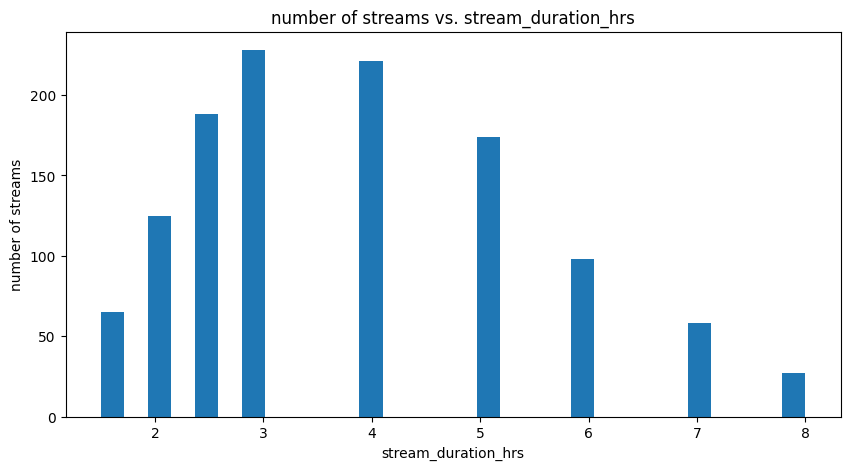

In [476]:
plt.figure(figsize=(10, 5))
plt.hist(df_streams["stream_duration_hrs"], bins=30)
plt.xlabel("stream_duration_hrs")
plt.ylabel("number of streams")
plt.title("number of streams vs. stream_duration_hrs")

Streams usually last around 3 hours.

Text(0.5, 1.0, 'number of streams vs. category_cleaned')

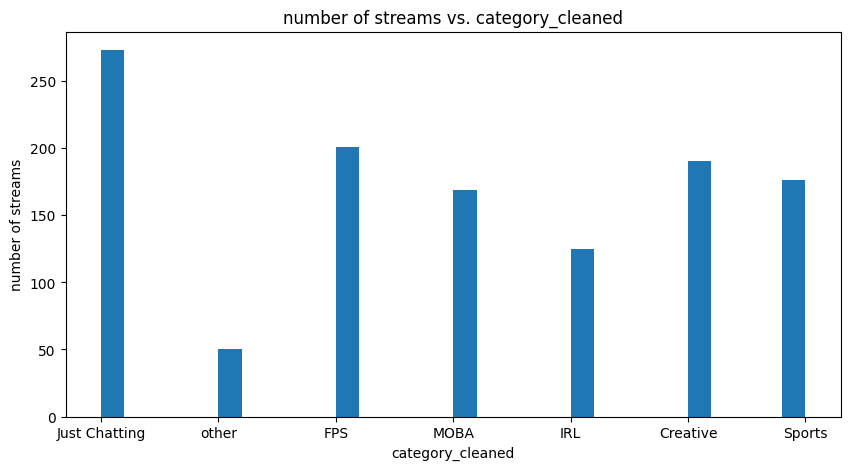

In [477]:
plt.figure(figsize=(10, 5))
plt.hist(df_streams["category_cleaned"], bins=30)
plt.xlabel("category_cleaned")
plt.ylabel("number of streams")
plt.title("number of streams vs. category_cleaned")

Streams are usually about Just Chatting.

### Category Information

In [478]:
print(df_streamers["category"].value_counts(), "\n")
print(df_streams["category_cleaned"].value_counts(), "\n")
print(df_viewers["preferred_category"].value_counts())

category
Just Chatting    18
FPS              13
Creative         13
MOBA             12
Sports           11
IRL               9
Name: count, dtype: int64 

category_cleaned
Just Chatting    273
FPS              201
Creative         190
Sports           176
MOBA             169
IRL              125
other             50
Name: count, dtype: int64 

preferred_category
Just Chatting    269
FPS              230
MOBA             161
IRL              120
Creative         117
Sports           103
Name: count, dtype: int64


In all of these columns, Just Chatting is the greatest by count.

In [503]:
df_streamers.groupby("category")[["total_followers_cleaned", "avg_concurrent_viewers"]].describe()

total_followers_cleaned                                         \
                                count          mean           std        min   
category                                                                       
Creative                         13.0  1.127692e+06  7.600675e+05   290000.0   
FPS                              13.0  4.012308e+06  3.703805e+06        0.0   
IRL                               9.0  3.423333e+06  3.660464e+06   380000.0   
Just Chatting                    18.0  3.742778e+06  4.421482e+06        0.0   
MOBA                             12.0  2.052500e+06  1.793839e+06   230000.0   
Sports                           11.0  5.581818e+06  5.332320e+06  1300000.0   

                                                            \
                     25%        50%        75%         max   
category                                                     
Creative        720000.0   940000.0  1500000.0   3100000.0   
FPS            1900000.0  2900000.0  6800000.0  11100000.0   
IRL             820000.0  1600000.0  4100000.0   9800000.0   
Just Chatting   600000.0  2250000.0  5575000.0  14500000.0   
MOBA            752500.0  1450000.0  2425000.0   5800000.0   
Sports         2150000.0  3800000.0  5800000.0  18700000.0   

              avg_concurrent_viewers                                      \
                               count          mean           std     min   
category                                                                   
Creative                        13.0   7856.000000   4980.053162  1011.0   
FPS                             13.0  34835.153846  41433.602810   678.0   
IRL                              9.0  32747.666667  39150.652006  2674.0   
Just Chatting                   18.0  44349.277778  45113.585936  3932.0   
MOBA                            12.0  17381.250000  17107.890153   634.0   
Sports                          11.0  46977.363636  48641.113094  4321.0   

                                                      
                    25%      50%       75%       max  
category                                              
Creative        5518.00   6870.0   9938.00   18345.0  
FPS            10414.00  14496.0  48998.00  141627.0  
IRL             6323.00  20511.0  38862.00  125683.0  
Just Chatting  10622.75  26943.5  65437.00  156401.0  
MOBA            5410.50   9279.0  25568.25   56574.0  
Sports         19208.50  31132.0  42696.00  151923.0

Sports has to most total followers on average and Just Chatting has the most average concurrent viewers.

In [501]:
df_streamers.groupby("category")["partner_status"].value_counts()

category       partner_status
Creative       True              10
               False              3
FPS            True              11
               False              2
IRL            True               7
               False              2
Just Chatting  True              17
               False              1
MOBA           True              10
               False              2
Sports         True              11
Name: count, dtype: int64

All categories has more partner_status True values than False.

In [502]:
df_streamers.groupby("category")["language_cleaned"].value_counts()

category       language_cleaned
Creative       English             12
               other                1
FPS            English             12
               other                1
IRL            English              7
               other                2
Just Chatting  English             13
               Spanish              4
               other                1
MOBA           English              9
               other                2
               Korean               1
Sports         English              8
               Portuguese           1
               other                1
               Spanish              1
Name: count, dtype: int64

English is used the most in each category.

### Task 3 Summary report

- 
- 
- 
- 

# Task 4: Dealing with Outliers and Missing Values

- Are there any missing values or outliers in the original data? Perform the analysis and report your findings.  
- Are there any outliers or missing values in the derived data? Perform the analysis and report your findings.  
- If there are no outliers or missing values, introduce 3–5% of missing values in a selected column and 1–2% of outliers in another column.  
- Experiment with two strategies for imputing missing values and two strategies for handling outliers. Show how each strategy affects the characteristics of the data.


In [485]:
#start code for Task 4 here

### Task 4 Summary report

# Task 5: Correlation and Behavioral Patterns

- Compute pairwise correlations between user features and the number of check-ins  
- Visualize the results using a correlation matrix (use a coolwarm color scheme and proper scaling)  
- Try Spearman rank correlation and explain when it is more appropriate than Pearson

In [486]:
# tast 5 code starts here

### Task 5 Summary report

# Task 6: Compare Behavior Across User Segments

- Segment users into 2–3 groups (e.g., by age bracket, account tire)  
- Compare their viewing behavior over time using boxplots or dot plots  
- Identify any outliers in group behavior and investigate them

In [487]:
# task 6 code start here

### Task 6 Summary report

# Task 7: Your Own EDA Questions

Formulate and explore two hypotheses of your own:  
- Propose questions based on curiosity (e.g., “Does a user's variety of categories influence morning vs. evening or session duration?”)  
- Use summary statistics and visualizations to answer each question  
- Briefly discuss what additional data would help you answer the questions more effectively


In [488]:
# task 7 code start here

### Task 7 Summary report

# Task 8: EDA Presentation (Insight Report)

Summarize your findings in a polished format:  
- Create 3–4 slides or a single-page report highlighting your most important insights  
- Include at least 2 charts and interpret them using clear, plain language  
- Apply Tufte’s principles: minimize chartjunk, maximize data-to-ink ratio, and ensure clear labeling  